# Chapitre 6 — Architecture GMIC

**🎯 Objectif :** comprendre l'architecture **GMIC** module par module, en suivant le schéma du papier, et faire une **inférence** avec un modèle pré-entraîné NYU — sans avoir besoin des données RSNA.
**⏱ Durée :** ~1–2 min (pas d'entraînement ; images d'exemple fournies par le dépôt GMIC).

**GMIC** (*Globally-aware Multiple Instance Classifier*, Shen et al. 2020) répond à une
difficulté précise : une mammographie fait **2944×1920**, mais les lésions qu'on y cherche
sont **minuscules** (quelques pixels pour des microcalcifications). Les deux réflexes
habituels échouent :

- **réduire l'image** pour la faire tenir en mémoire → on efface justement ce qu'on cherche ;
- **un gros CNN en pleine résolution** (type ResNet-34) → ça ne tient pas en mémoire GPU.

La réponse de GMIC est de **découper le problème en trois modules**, chacun avec son
compromis propre :

1. un module **global** *à faible capacité* qui voit l'image **entière**, en **pleine
   résolution** — la mémoire est économisée en allégeant le *réseau*, pas en réduisant
   l'*image*. Il produit une **carte de saillance** grossière (46×30) qui dit *où* regarder ;
2. un module **local** *à forte capacité* qui zoome sur les **K=6 patchs 256×256** désignés
   par cette carte — la capacité est dépensée là où le détail compte ;
3. un module de **fusion** qui recombine contexte global et détails locaux pour le score final.

> ⚠️ Contresens fréquent : ce n'est **pas** le module global qui travaille en basse
> résolution. Il reçoit bien l'image en 2944×1920 ; c'est sa **sortie** (la carte 46×30) qui
> est grossière.

On part du **schéma original du papier** (Fig. 2, livré dans le dépôt), puis chaque section
reprend une de ses boîtes et explique le **pourquoi** de sa conception.

GMIC est le sous-module `modules/GMIC` (monté dans le conteneur), avec ses **5 poids
pré-entraînés NYU** (`models/sample_model_*.p`) et des **images d'exemple** — ce
notebook tourne sans données RSNA. La publication utilise la **moyenne des 5 modèles**
(un ensemble) ; ici on charge le modèle 1.

Device : cuda


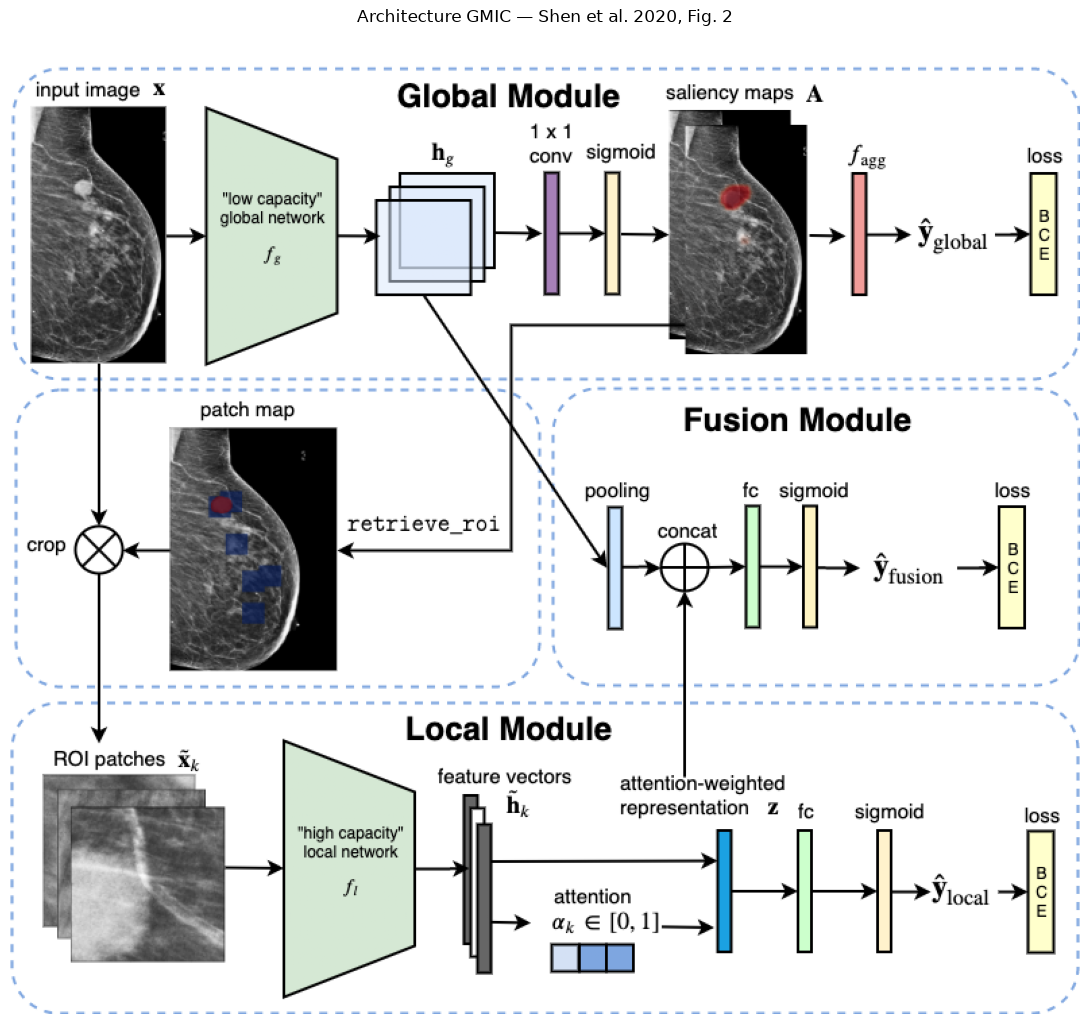

In [1]:
import os, sys, glob, warnings
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import cv2
from course_utils import gmic_dir, pick_device
warnings.filterwarnings('ignore')
torch.manual_seed(0)

GMIC_DIR = gmic_dir()                 # sous-module modules/GMIC
sys.path.insert(0, GMIC_DIR)
DEVICE = pick_device(verbose=False)
print('Device :', DEVICE)

# Le VRAI schéma du papier (Shen et al. 2020, Fig. 2), montré tel quel plutôt qu'un
# flowchart maison : il porte les notations exactes (x, h_g, A, z, alpha_k...) que la
# légende ci-dessous relie une à une au code réel.
img_fig = plt.imread(os.path.join(GMIC_DIR, 'mia_structure.png'))
plt.figure(figsize=(11, 11))
plt.imshow(img_fig); plt.axis('off')
plt.title('Architecture GMIC — Shen et al. 2020, Fig. 2')
plt.tight_layout(); plt.show()

## Le schéma, boîte par boîte

| Boîte du schéma | Notation papier | Code réel | Rôle |
|---|---|---|---|
| input image | $\mathbf{x}$ | `img_t` | mammographie prétraitée (ch3), 2944×1920 |
| "low capacity" global network | $f_g$ | `model.ds_net` (ResNet-22) | voit l'image **entière** en pleine résolution |
| *(feature maps)* | $\mathbf{h}_g$ | sortie de `ds_net` | réutilisée par le module de fusion plus loin |
| 1×1 conv + sigmoid | — | `model.left_postprocess_net` | $\mathbf{h}_g$ → 2 canaux (benign / malignant) |
| saliency maps | $\mathbf{A}$ | `model.saliency_map` | carte 46×30, proba de lésion par cellule |
| $f_{agg}$ (top t% pooling) | $f_{agg}$ | `model.aggregation_function` | $\mathbf{A}$ → score scalaire `y_global` |
| retrieve_roi / patch map | — | `model.retrieve_roi_crops` | choisit K=6 fenêtres 256×256 dans $\mathbf{A}$ |
| crop | — | `model._retrieve_crop` | découpe ces fenêtres dans l'image **originale** |
| ROI patches | $\tilde{\mathbf{x}}_k$ | `model.patches` | les 6 patchs en pleine résolution |
| "high capacity" local network | $f_l$ | `model.dn_resnet` (ResNet-18) | zoome en détail sur chaque patch |
| feature vectors | $\tilde{\mathbf{h}}_k$ | — | vecteur 512-dim par patch |
| attention | $\alpha_k$ | `mil_attn_V` / `mil_attn_U` / `mil_attn_w` | poids ∈[0,1] par patch (Gated Attention) |
| attention-weighted representation | $\mathbf{z}$ | — | moyenne pondérée des $\tilde{\mathbf{h}}_k$ |
| pooling *(module fusion)* | $\mathrm{GMP}(\mathbf{h}_g)$ | — | réduit $\mathbf{h}_g$ à un vecteur (même forme que $\mathbf{z}$) |
| concat + fc + sigmoid | — | `model.fusion_dnn` | $[\mathrm{GMP}(\mathbf{h}_g), \mathbf{z}] \to$ `y_fusion` |
| loss ×3 | BCE + β·L1($\mathbf{A}$) | — | 3 têtes supervisées séparément (détail en Étape 5) |

Cette table est un repère à consulter en cours de route. Les cellules qui suivent
parcourent le schéma dans l'ordre (saillance → ROI → local+attention → fusion) et
creusent le **pourquoi** de chaque choix.

In [2]:
# ── Boîte « input image x » du schéma ────────────────────────────────────────
# Les images d'exemple du dépôt GMIC sont livrées BRUTES (non recadrées) : on refait donc
# ici, en miniature, le prétraitement du ch3 — sinon le modèle recevrait une image au
# mauvais format et les cartes de saillance seraient décalées.
GMIC_H, GMIC_W = 2944, 1920                        # la taille sur laquelle GMIC a été entraîné
imgs = sorted(glob.glob(os.path.join(GMIC_DIR, 'sample_data/images', '*.png')))
assert imgs, 'Images GMIC introuvables.'
raw = cv2.imread(imgs[0], cv2.IMREAD_UNCHANGED).astype(np.float32)

# Crop du fond noir : seuil à 5 % du max = tout ce qui est plus sombre est considéré comme
# fond (le sein est bien plus lumineux). Version simplifiée du crop_mammogram.py du ch3,
# suffisante ici car on ne traite qu'UNE image de démo.
mask = raw > 0.05 * raw.max()
ys, xs = np.where(mask)
raw = raw[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
# INTER_AREA : on RÉDUIT (moyenne des pixels), évite l'aliasing — cf. ch3 étape 4.
raw = cv2.resize(raw, (GMIC_W, GMIC_H), interpolation=cv2.INTER_AREA)
# z-score : la normalisation que le ch3 laisse volontairement au chargement (elle produit
# des valeurs négatives, non stockables dans un PNG uint8). GMIC a été entraîné sur des
# entrées centrées-réduites : lui donner du [0, 255] brut fausserait toutes ses activations.
norm = (raw - raw.mean()) / max(raw.std(), 1e-5)
# [None, None] ajoute 2 axes en tête : (H, W) -> (1, 1, H, W) = (N, C, H, W). PyTorch attend
# toujours un axe batch et un axe canal, même pour une seule image en niveaux de gris.
img_t = torch.tensor(norm[None, None], dtype=torch.float32).to(DEVICE)
print('Entrée modèle :', tuple(img_t.shape), '(N, C, H, W)')
print('Image :', os.path.basename(imgs[0]))

Entrée modèle : (1, 1, 2944, 1920) (N, C, H, W)
Image : 0_L-CC.png


## Partie I — La brique de base : `BasicBlock`

Le schéma ci-dessus montre les modules comme des **boîtes** (`f_g`, `f_l`) sans dire ce qu'il y
a dedans. Or les deux sont des **ResNet**, c'est-à-dire un empilement d'une seule brique
répétée : le `BasicBlock`. Le détail du ResNet-22 de `f_g` figure dans le papier (Fig. 2,
colonne de droite) mais **pas** dans l'image livrée par le dépôt ; le voici, lu directement
dans le code (`GlobalNetwork`, [modules.py](../modules/GMIC/src/modeling/modules.py)) :

`conv 7×7 (16 canaux, stride 2)` → `maxpool 3×3 stride 2` → **10 `BasicBlock`** groupés par 2,
avec doublement des canaux à chaque groupe : **16 → 32 → 64 → 128 → 256**. Quatre de ces
groupes divisent aussi la résolution par 2.

**D'où vient le facteur 64 de l'étape 1 ?** De ce cumul : `stride 2` (conv initiale) ×
`stride 2` (maxpool) × 2×2×2×2 (les quatre groupes qui réduisent) = **64**. C'est ce qui fait
passer 2944×1920 à 46×30 — ce n'est donc pas un réglage arbitraire mais la **conséquence
mécanique** de l'architecture.

**Pourquoi des blocs *résiduels* ?** Un `BasicBlock` empile deux `conv3×3 → BN → ReLU`, mais
surtout il **rajoute son entrée à sa sortie** : $F(x) + x$. Sans ce raccourci, empiler
beaucoup de couches dégrade l'entraînement (le gradient s'atténue en remontant). Avec lui, le
gradient dispose d'un **chemin direct** vers les couches basses, et chaque bloc n'a plus qu'à
apprendre une *correction* à ce qu'il reçoit — d'où la possibilité d'aller aussi profond.

> Détail d'implémentation : GMIC utilise **deux variantes**. `BasicBlockV1` (ci-dessous, celle
> du module **local**) applique `conv → BN → ReLU` puis additionne ; `BasicBlockV2` (module
> **global**) fait `BN → ReLU → conv`, la version « pre-activation », réputée un peu plus
> stable en profondeur. Même idée, ordre différent.

Visualisons les feature maps d'un `BasicBlockV1` sur un patch.

BasicBlockV1(64->64) : 73984 params


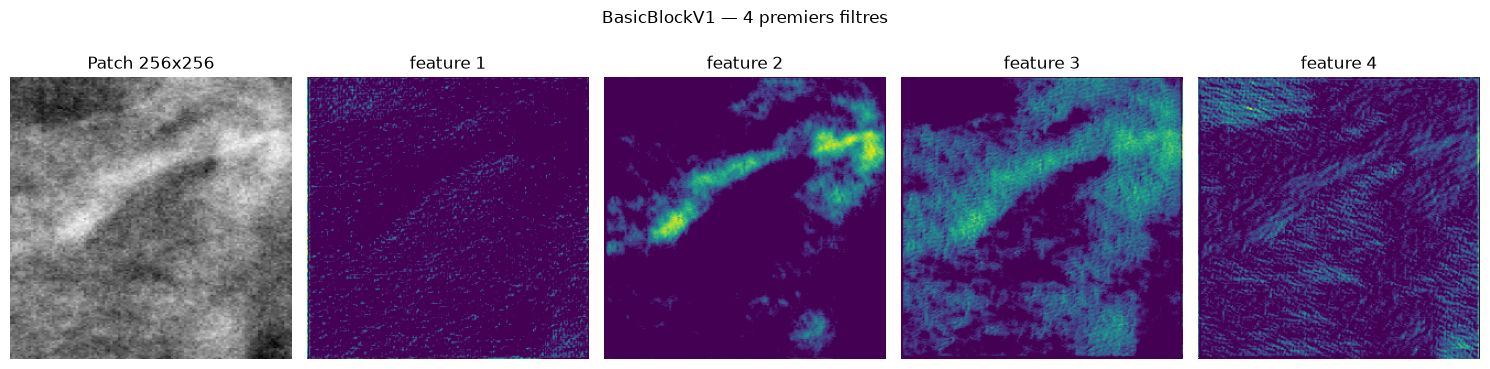

In [3]:
from src.modeling.modules import BasicBlockV1

block = BasicBlockV1(inplanes=64, planes=64)
print('BasicBlockV1(64->64) :', sum(p.numel() for p in block.parameters()), 'params')

crop = norm[GMIC_H // 2 - 128: GMIC_H // 2 + 128, GMIC_W // 2 - 128: GMIC_W // 2 + 128]
x = torch.tensor(crop[None, None], dtype=torch.float32)
# stem = simple adaptateur 1->64 canaux (poids ALÉATOIRES, non entraînés) : BasicBlockV1
# attend 64 canaux en entrée, le patch n'en a qu'1. Sert juste à observer la FORME des
# features produites par le bloc résiduel, pas des activations GMIC réelles.
stem = nn.Conv2d(1, 64, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    feats = block(stem(x))            # (1, 64, 256, 256)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].imshow(crop, cmap='gray'); axes[0].set_title('Patch 256x256'); axes[0].axis('off')
for i, ax in enumerate(axes[1:]):
    ax.imshow(feats[0, i].numpy(), cmap='viridis'); ax.set_title(f'feature {i+1}'); ax.axis('off')
plt.suptitle('BasicBlockV1 — 4 premiers filtres'); plt.tight_layout(); plt.show()

## Partie II — Le modèle complet + poids NYU

On instancie le `GMIC` officiel et on charge `sample_model_1.p`. Le dictionnaire `params`
ci-dessous n'est pas décoratif : **chaque clé fixe une des quantités du schéma**, et une
valeur incohérente casse le pipeline silencieusement (patchs mal placés, `assert` sur la
taille de carte, etc.). D'où viennent-elles :

| Clé | Valeur | Pourquoi celle-là |
|---|---|---|
| `cam_size` | `(46, 30)` | Taille de la carte $\mathbf{A}$ = 2944/64 × 1920/64. **Doit** correspondre à ce que produit `ds_net` : le code `assert` l'égalité, car les coordonnées des ROI sont converties via ce repère. |
| `K` | `6` | Nombre de ROI. Valeur du papier ; monter K coûte du calcul local et finit par ajouter surtout du bruit. |
| `crop_shape` | `(256, 256)` | Taille des patchs, en **pixels de l'image d'origine**. |
| `percent_t` | `0.02` | Le « top 2 % » du pooling d'agrégation (Étape 1). Chaque poids `sample_model_*.p` a été entraîné avec **son propre** `percent_t` : le changer sans changer de checkpoint dégrade le score. |
| `post_processing_dim` | `256` | Nombre de canaux en sortie de `ds_net`, donc l'entrée de la conv 1×1. Doit matcher l'architecture. |
| `num_classes` | `2` | *benign* et *malignant* — deux sigmoïdes **indépendantes**, pas un softmax (cf. Étape 1). |
| `use_v1_global` | `False` | `False` → le module global est le **ResNet-22** du papier ; `True` basculerait sur un ResNet-18, non compatible avec ces poids. |

`strict=False` au chargement : le checkpoint contient **une clé en trop** (non utilisée par
le `forward`), qu'on veut simplement ignorer plutôt que de faire échouer le chargement.
Le compte affiché (`0` manquante / `1` en trop) est là pour le **vérifier** — s'il y avait
des clés *manquantes*, une partie du réseau tournerait avec des poids aléatoires, et les
résultats seraient silencieusement faux.

> 🔍 **Lis bien la sortie `y_fusion` ci-dessous : `[[0.2908, 0.0631]]`.** Ces deux nombres
> somment à **0,354**, pas à 1 — la preuve directe qu'il ne s'agit **pas** d'un softmax mais de
> deux sigmoïdes indépendantes : `0.2908` = P(lésion bénigne), `0.0631` = P(lésion maligne),
> deux questions oui/non séparées (cf. Étape 1). D'où le `[-1]` partout dans le notebook pour
> attraper la malignité.

In [4]:
from src.modeling.gmic import GMIC

params = {
    'device_type': 'gpu' if DEVICE.type == 'cuda' else 'cpu',
    'gpu_number': 0,
    'cam_size': (46, 30),
    'K': 6,
    'crop_shape': (256, 256),
    'percent_t': 0.02,
    'use_v1_global': False,
    'post_processing_dim': 256,
    'num_classes': 2,
}
model = GMIC(params).to(DEVICE).eval()
# weights_only=True : vérifié -> ce checkpoint NYU est un simple state_dict de tenseurs
# (torch.load le charge sans exécuter de code arbitraire, la voie sûre par défaut).
ckpt = torch.load(os.path.join(GMIC_DIR, 'models/sample_model_1.p'),
                  map_location=DEVICE, weights_only=True)
missing, unexpected = model.load_state_dict(ckpt, strict=False)
print('params totaux :', f'{sum(p.numel() for p in model.parameters()):,}')
print('clés manquantes :', len(missing), '| clés en trop :', len(unexpected))

with torch.no_grad():
    y_fusion = model(img_t)           # déclenche tout le pipeline
print('y_fusion :', y_fusion.detach().cpu().numpy().round(4))

params totaux : 14,110,322
clés manquantes : 0 | clés en trop : 1
y_fusion : [[0.2908 0.0631]]


## Partie III — Ouvrir la boîte : parcourir le schéma étape par étape

Le `forward` ne renvoie que `y_fusion`, mais il **stocke chaque intermédiaire en attribut**
du modèle : `saliency_map`, `patch_locations`, `patches`, `patch_attns`, `y_global`,
`y_local`, `y_fusion`. Ce n'est pas un hasard d'implémentation — c'est ce qui rend GMIC
**interprétable** : on peut demander au modèle *où* il a regardé et *combien* chaque zone a
pesé, sans le réexécuter. Les quatre étapes qui suivent parcourent le schéma dans l'ordre en
affichant, à chaque fois, l'objet réel produit par le forward qu'on vient de lancer.

### Étape 1 — Carte de saillance $\mathbf{A}$ (module global)

**Le geste.** $\mathbf{h}_g = f_g(\mathbf{x})$ puis $\mathbf{A} = \mathrm{sigm}(\mathrm{conv}_{1\times1}(\mathbf{h}_g))$ — la boîte "low capacity global network" suivie de la boîte "1×1 conv + sigmoid" du schéma.

**Pourquoi un réseau *à faible capacité* ?** C'est le cœur du compromis de GMIC. Le réflexe habituel face à une image trop grosse pour la mémoire GPU est de la **réduire** — mais sur une mammographie, réduire *détruit l'information utile* : les marges de lésion se brouillent et les microcalcifications (quelques pixels) disparaissent. GMIC fait donc l'inverse : il **garde la pleine résolution 2944×1920** et économise la mémoire en **allégeant le réseau**. Concrètement, `ds_net` est un ResNet-22 qui, comparé à un ResNet classique, a **un bloc résiduel en plus** (plus profond → champ réceptif plus large, il « voit » des structures étendues) mais seulement **un quart des filtres** par couche (moins d'unités cachées → moins de mémoire).

**Pourquoi une conv 1×1 ?** Elle ne regarde aucun voisinage : elle recombine juste les **256 canaux** de $\mathbf{h}_g$ en **2 canaux**, un par classe. C'est exactement le rôle d'un classifieur, mais appliqué **à chaque position** de la grille au lieu de l'image entière — d'où une *carte* de probabilités et non un score unique.

**Pourquoi 46×30 ?** C'est 2944/64 et 1920/64 : les convolutions et poolings successifs de `ds_net` divisent la résolution par 64 au total. Chaque cellule de la carte résume donc un bloc d'environ 64×64 pixels.

**Pourquoi 2 canaux et pas 2 classes exclusives ?** Les 2 sorties sont *benign* et *malignant*, chacune passée dans sa **propre sigmoïde** — pas dans un softmax commun. Un sein peut très bien présenter les deux à la fois, ou aucun des deux : ce sont deux questions oui/non indépendantes. C'est pour ça que le code prend le **dernier canal** (`sal[-1]`) quand il veut la malignité, et que la loss sera une BCE par classe (Étape 5) et non une cross-entropy.

**Pourquoi un pooling « top 2 % » pour en tirer un score ?** Il faut bien résumer la carte en un scalaire `y_global`, et les deux extrêmes classiques échouent tous les deux ici :
- la **moyenne** (GAP, = top 100 %) **dilue** le signal — l'immense majorité des cellules est du tissu sain, une petite lésion se noie dans la moyenne ;
- le **max** (GMP, = top 1 cellule) ne rétropropage le gradient que par **une seule** position → apprentissage lent et instable.

`percent_t=0.02` prend la moyenne des **2 % de cellules les plus actives**, soit `round(46×30×0.02)` = **28 cellules** : assez pour un gradient stable, assez peu pour ne pas diluer. C'est un curseur *entre* GAP et GMP.

**Et c'est ça, la « supervision faible ».** On ne peut pas comparer $\mathbf{A}$ à la vérité terrain : le label ne dit *que* « ce sein a un cancer », jamais *où*. Ce pooling est le pont — il transforme la carte en une prédiction image-level comparable au label, et le gradient qui remonte apprend à `ds_net` **où regarder** sans qu'on le lui ait jamais montré. Aucune annotation pixel n'est nécessaire, contrairement à Faster R-CNN.

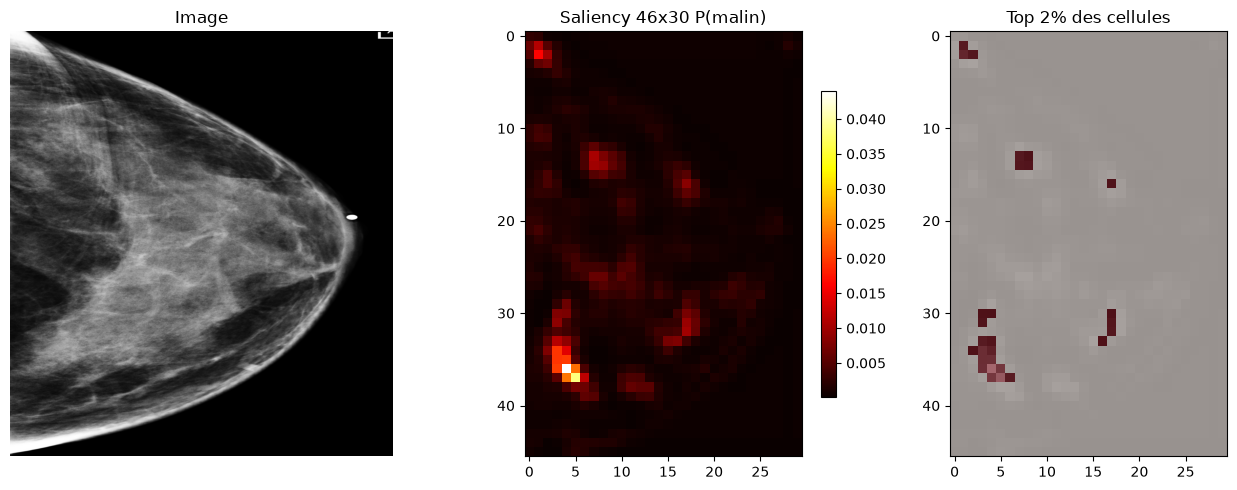

In [5]:
sal = model.saliency_map.detach().cpu().numpy()[0]        # (num_classes, 46, 30)
sal_malig = sal[-1]                                        # dernier canal = malignant
thr = np.percentile(sal_malig, 98)

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].imshow(raw, cmap='gray', aspect='auto'); ax[0].set_title('Image'); ax[0].axis('off')
im = ax[1].imshow(sal_malig, cmap='hot'); ax[1].set_title('Saliency 46x30 P(malin)')
plt.colorbar(im, ax=ax[1], fraction=0.04)
ax[2].imshow(sal_malig, cmap='gray'); ax[2].imshow(sal_malig >= thr, cmap='Reds', alpha=0.6)
ax[2].set_title('Top 2% des cellules')
plt.tight_layout(); plt.show()

### Étape 2 — Choisir les K=6 ROI : `retrieve_roi` (boîtes "patch map" → "crop")

**Le geste.** $\{\tilde{\mathbf{x}}_k\} = \texttt{retrieve\_roi}(\mathbf{A})$ : on lit la carte de saillance pour décider **où** zoomer, puis on découpe ces fenêtres dans l'image d'origine.

**Pourquoi passer par la carte plutôt que balayer l'image ?** Pavée en fenêtres 256×256, une image 2944×1920 en compterait **77** (11×7), toutes à faire passer dans un gros réseau — trop coûteux. La carte de saillance a déjà fait le tri grossier : on ne garde que les **6** fenêtres les plus prometteuses. C'est le principe « chercher grossièrement, puis regarder de près », qui imite un radiologue balayant l'image avant de fixer les zones suspectes.

**L'algorithme, ligne par ligne** (Algorithme 1 du papier, `RetrieveROIModule` dans le code) :

1. **Normalisation min-max de chaque classe séparément.** $\tilde{A}^c = \frac{A^c - \min A^c}{\max A^c - \min A^c}$. *Pourquoi ?* Les deux cartes (benign, malignant) n'ont pas les mêmes plages de valeurs. Sans remise à l'échelle, la classe dont les activations sont globalement plus fortes écraserait l'autre à l'étape suivante — on veut que les deux pèsent également dans le choix des zones à inspecter.
2. **Somme sur les classes** : $A^* = \sum_c \tilde{A}^c$. *Pourquoi une seule carte ?* Les patchs sont choisis **une fois pour les deux classes**, pas 6 par classe : une zone suspecte mérite d'être inspectée qu'elle évoque du bénin ou du malin.
3. **Fenêtre glissante et score = somme des valeurs** dans la fenêtre. Détail concret : la fenêtre de 256×256 **pixels** correspond, sur la grille 46×30, à seulement `round(256 × 46/2944)` = **4×4 cellules** — la recherche se fait donc sur une toute petite grille, ce qui la rend quasi gratuite.
4. **Sélection gloutonne**, K=6 fois : on prend la fenêtre de score maximal, puis — c'est la « reset rule » — on **met ses cellules à zéro** dans $A^*$ avant de chercher la suivante. *Pourquoi ?* Sans cela, les 6 fenêtres se superposeraient toutes sur le même point chaud et on aurait 6 fois la même information. La mise à zéro force la diversité spatiale.
5. **Changement de repère** : les coordonnées trouvées sont sur la grille 46×30, on les remet à l'échelle de l'image 2944×1920 (`_convert_crop_position`, simple règle de trois) — puis on découpe **dans l'image d'origine**, pas dans la carte. C'est essentiel : la carte est grossière, mais le patch extrait est en **pleine résolution**, avec tout le détail fin.

**Pourquoi glouton et pas optimal ?** C'est assumé comme une **heuristique** : ce n'est qu'un mécanisme de *proposition*, l'attention de l'étape suivante corrigera en pondérant les patchs. Chercher la combinaison optimale de 6 fenêtres coûterait cher pour un gain nul.

> Les coordonnées renvoyées sont le **coin supérieur gauche** de chaque fenêtre (`crop_method = "upper_left"`) — c'est pourquoi la cellule suivante dessine les rectangles à partir de ce point.

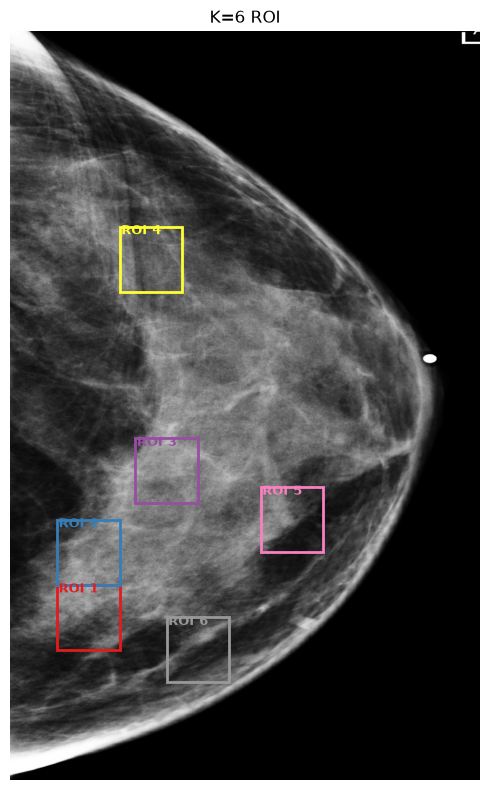

In [6]:
locs = np.asarray(model.patch_locations)[0]              # (K, 2) -> (row, col)
fig, ax = plt.subplots(figsize=(5, 8))
ax.imshow(raw, cmap='gray', aspect='auto')
colors = plt.cm.Set1(np.linspace(0, 1, len(locs)))
for k, (loc, col) in enumerate(zip(locs, colors)):
    r, c = int(loc[0]), int(loc[1])
    ax.add_patch(plt.Rectangle((c, r), 256, 256, lw=2, edgecolor=col, facecolor='none'))
    ax.text(c + 6, r + 30, f'ROI {k+1}', color=col, fontsize=9, fontweight='bold')
ax.set_title('K=6 ROI'); ax.axis('off'); plt.tight_layout(); plt.show()

### Étapes 3 & 4 — Module local $f_l$ et attention (le « MIC » de GMIC)

**Le geste.** $\tilde{\mathbf{h}}_k = f_l(\tilde{\mathbf{x}}_k)$ pour chacun des 6 patchs, puis $\mathbf{z} = \sum_k \alpha_k \tilde{\mathbf{h}}_k$ — les boîtes "high capacity local network", "attention" et "attention-weighted representation".

**Pourquoi un réseau *à forte capacité* ici, alors que le global était volontairement bridé ?** Parce que la contrainte a changé. Le module global devait avaler 2944×1920 → il fallait l'alléger. Le module local ne voit que des **patchs 256×256**, soit ~86× moins de pixels : on peut donc y dépenser un vrai ResNet-18 sans exploser la mémoire. C'est toute la logique de GMIC — **mettre la capacité là où le détail compte**, sur les quelques zones qui le méritent, plutôt que partout uniformément.

**Une bizarrerie du code qui vaut une explication.** Le patch est en niveaux de gris (1 canal), mais `dn_resnet` est construit avec `input_channels=3`. Le forward fait donc `x_crop.expand(-1, 3, -1, -1)` : il **réplique** le canal gris 3 fois pour imiter du RGB. Pourquoi ne pas avoir adapté la première conv à 1 canal, comme on l'a fait pour ResNet-18 au ch4 ? Parce qu'ici on ne réutilise pas de poids ImageNet 3-canaux : c'est simplement la convention de l'implémentation. À noter que `.expand` ne **copie rien** — il crée une vue avec un *stride* nul sur cet axe, donc le coût mémoire est nul.

Après le ResNet, un **global average pooling** (`res.mean(dim=2).mean(dim=2)`) réduit chaque patch à un **vecteur 512-dim** : on jette la position *à l'intérieur* du patch pour ne garder que « qu'y a-t-il dedans ».

**Pourquoi une attention, et pas juste la moyenne des 6 patchs ?** C'est le point clé, et il découle directement de l'étape 2 : les patchs ont été choisis sur une carte **grossière**, donc leur pertinence réelle **varie énormément** — sur 6 patchs, certains tombent sur du tissu banal. Les moyenner à poids égal noierait le seul patch informatif dans 5 patchs de bruit. L'attention apprend à **allouer son regard** : un poids $\alpha_k$ par patch, avec $\sum_k \alpha_k = 1$ (softmax) — c'est une répartition *relative* de l'importance.

C'est exactement le cadre du **Multiple Instance Learning** (le « MIC » du nom GMIC) : l'image est un *sac* de 6 instances, on ne connaît le label que **du sac** (« ce sein a un cancer »), jamais de chaque instance. L'attention est ce qui permet d'apprendre quelles instances portent le signal.

**Pourquoi une attention *« gated »* (Ilse et al. 2018) ?** La formule est
$$\alpha_k = \mathrm{softmax}_k\big(\mathbf{w}^\top(\tanh(V\tilde{\mathbf{h}}_k) \odot \mathrm{sigm}(U\tilde{\mathbf{h}}_k))\big)$$
avec deux projections **en parallèle** ($V$ et $U$, 512→128) dont les sorties sont multipliées terme à terme. Le $\tanh$ seul serait quasi **linéaire** au voisinage de 0, ce qui limiterait fortement l'expressivité du score d'attention ; la branche sigmoïde agit comme une **porte** apprise (d'où « gated ») qui peut atténuer ou laisser passer chaque dimension indépendamment. On gagne en souplesse pour un coût dérisoire (~131 k paramètres : `mil_attn_V`, `mil_attn_U`, `mil_attn_w`).

Le vecteur $\mathbf{z}$ ainsi obtenu passe dans une couche linéaire + sigmoïde (`classifier_linear`) pour donner `y_local`.

> 🔍 **Trois choses à observer dans la sortie ci-dessous**, qui valident tout ce qui précède :
> 1. Les 6 poids **somment exactement à 1** (0,216 + 0,174 + 0,143 + 0,106 + 0,112 + 0,249 = 1,000) — c'est le softmax.
> 2. Ils sont **loin d'être uniformes** : de 0,106 à 0,249, soit un rapport de 2,3× (l'uniforme serait 1/6 ≈ 0,167). L'attention *sert* donc réellement à quelque chose.
> 3. Le patch le plus lourd est **ROI 6**, alors que ROI 1 est celui que la sélection gloutonne avait jugé le plus prometteur. C'est exactement le rôle de rattrapage annoncé à l'étape 2 : **l'ordre de la carte grossière n'est pas l'ordre de l'importance finale**, et c'est l'attention — qui a vu les patchs en pleine résolution — qui tranche.

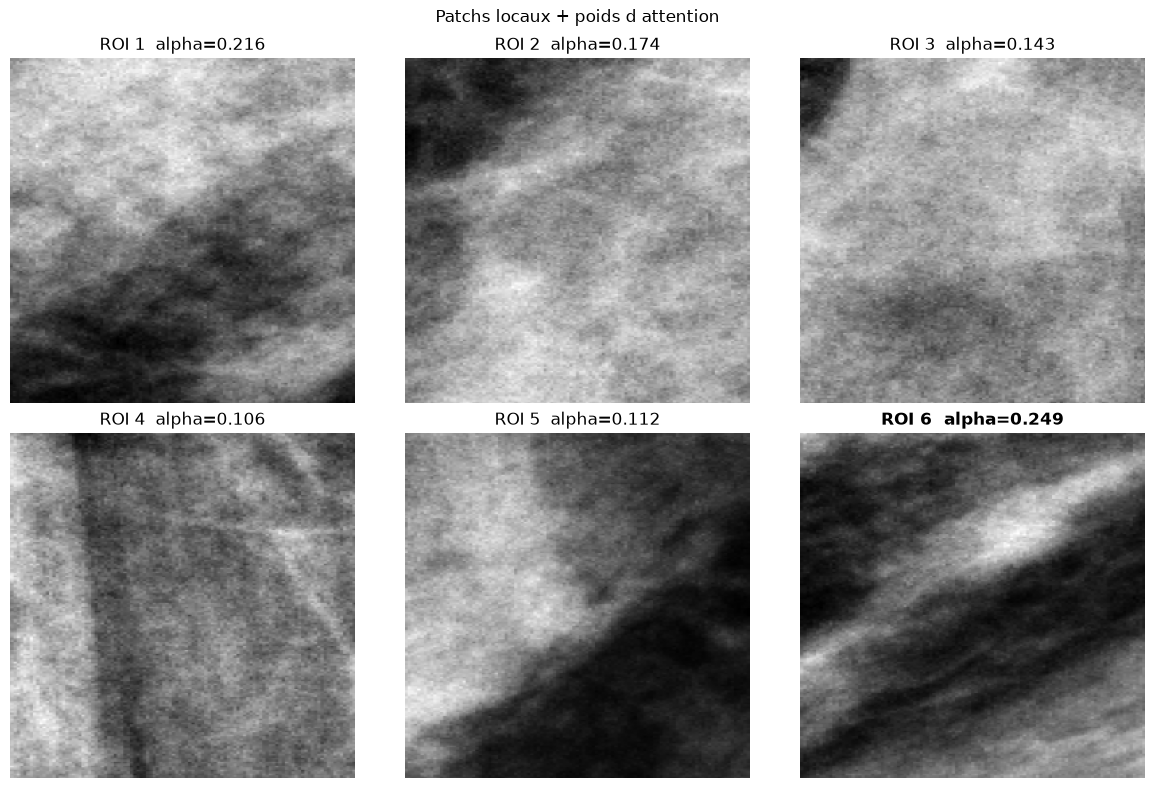

In [7]:
# patch_attns est un tenseur qui reste sur le GPU (les poids d'attention sortent du forward) :
# numpy ne sait pas lire la mémoire GPU, il faut d'abord .cpu(). patches, lui, est déjà un numpy
# côté GMIC -> np.asarray suffit. Ce helper gère les deux cas (tenseur GPU/CPU ou numpy).
def _np(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

patches = _np(model.patches)[0]                   # (K, 256, 256)
attn = _np(model.patch_attns).reshape(-1)         # (K,)
best = int(attn.argmax())
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for k, ax in enumerate(axes.flat):
    ax.imshow(patches[k], cmap='gray')
    ax.set_title(f'ROI {k+1}  alpha={attn[k]:.3f}',
                 fontweight='bold' if k == best else 'normal')
    ax.axis('off')
plt.suptitle('Patchs locaux + poids d attention'); plt.tight_layout(); plt.show()

### Étape 5 — Module de fusion et les 3 têtes

**Le geste.** $\hat{y}_{fusion} = \mathrm{sigm}\big(\mathbf{w}_f\,[\mathrm{GMP}(\mathbf{h}_g),\ \mathbf{z}]^\top\big)$ — les boîtes "pooling", "concat" et "fc + sigmoid" du schéma.

**Pourquoi une fusion, alors qu'on a déjà deux scores ?** C'est **l'apport de ce papier de 2020** par rapport à la version préliminaire de 2019, et la justification est clinique : le diagnostic dépend *à la fois* du détail local et du contexte global. L'exemple du papier est parlant — les microcalcifications sont fréquentes dans le bénin **comme** dans le malin ; c'est leur **distribution** (en réseau ductal, visible seulement à l'échelle globale) qui signe la malignité. Autrement dit, **le même détail local ne veut pas dire la même chose selon le contexte global** : il faut donc un module qui voit les deux ensemble.

**Comment on rend $\mathbf{h}_g$ combinable avec $\mathbf{z}$ ?** $\mathbf{h}_g$ est une *carte* (256 canaux × 46 × 30), $\mathbf{z}$ un *vecteur* (512) : on ne peut pas les concaténer tels quels. Un **global max pooling** réduit donc $\mathbf{h}_g$ à 256 valeurs, une par canal (dans le code : deux `torch.max` successifs, sur H puis sur W). Chaque valeur répond à « ce motif est-il présent **quelque part** dans le sein ? » — un max, pas une moyenne, pour la même raison qu'à l'étape 1 : une lésion est locale, la moyenner sur toute l'image la diluerait. Puis `concat` → 256 + 512 = **768** dimensions, et une seule couche `Linear(768, 2)` (`fusion_dnn`) produit le score final.

**Le point à ne pas manquer : la fusion combine des *représentations*, pas des *scores*.** Regarde les valeurs affichées ci-dessous — `y_fusion` n'est pas la moyenne de `y_global` et `y_local`, et n'a aucune raison de l'être. La couche de fusion travaille sur les **768 features** brutes, ce qui lui laisse la liberté d'apprendre des combinaisons fines (« ce motif global *plus* ce détail local ⇒ suspect ») qu'une simple moyenne de deux probabilités ne pourrait jamais exprimer.

**Alors à quoi servent `y_global` et `y_local` ?** À l'inférence : **à rien** — le `forward` de GMIC ne renvoie que `y_fusion`, et le code d'origine le dit explicitement (*« y_global is not directly used in inference »*). Ils existent pour l'**entraînement**, où les trois têtes sont supervisées ensemble :

$$\mathcal{L} = \sum_{c \in \{b, m\}} \mathrm{BCE}(y^c, \hat{y}^c_{global}) + \mathrm{BCE}(y^c, \hat{y}^c_{local}) + \mathrm{BCE}(y^c, \hat{y}^c_{fusion}) + \beta \underbrace{\textstyle\sum_{i,j} |A^c_{i,j}|}_{\text{L1 sur la saillance}}$$

*Pourquoi superviser les trois plutôt que la seule sortie utile ?* Parce que sans supervision directe de `y_global`, **rien ne forcerait la carte $\mathbf{A}$ à être pertinente** — or c'est elle qui choisit les 6 ROI. Une carte apprise « au hasard » donnerait 6 patchs sans intérêt, et tout l'édifice local s'écroulerait. Chaque tête tire donc sa propre branche : `y_global` entraîne `ds_net`, `y_local` entraîne `dn_resnet` + l'attention, `y_fusion` entraîne la combinaison.

*Et le terme L1 ?* Il pousse la carte de saillance à être **parcimonieuse**. Sans lui, $\mathbf{A}$ pourrait s'allumer un peu partout tout en gardant un bon score top-2 % — les zones désignées ne voudraient plus rien dire, et l'interprétabilité (l'argument central de GMIC) serait perdue.

> Ces `BCE` sont appliquées à des sorties **déjà sigmoïdées** — le piège `BCEWithLogits` est détaillé au chapitre 7, qui implémente cette loss.

In [8]:
def malig(t):
    return float(t.detach().cpu().reshape(-1)[-1])       # dernier canal = malignant

print(f'y_global  (branche globale)        : {malig(model.y_global):.4f}')
print(f'y_local   (branche locale + attn)  : {malig(model.y_local):.4f}')
print(f'y_fusion  (FUSION = sortie modèle) : {malig(model.y_fusion):.4f}')

y_global  (branche globale)        : 0.0145
y_local   (branche locale + attn)  : 0.0345
y_fusion  (FUSION = sortie modèle) : 0.0631


## Récap — pourquoi cette architecture, et pas un simple ResNet

Toute la conception de GMIC découle d'**une** tension : image énorme, lésions minuscules,
mémoire GPU finie. Chaque module est une réponse à un morceau de ce problème :

| Contrainte | Réponse de GMIC |
|---|---|
| Réduire l'image effacerait les microcalcifications | Module global **à faible capacité** → pleine résolution conservée |
| Un CNN bridé rate les détails fins | Module local **à forte capacité**, mais seulement sur 6 patchs |
| On ne sait pas *où* sont les lésions (labels image-level) | Pooling **top t %** → supervision faible, la localisation s'apprend seule |
| Les 6 patchs viennent d'une carte grossière, donc inégaux | **Attention MIL** → pondération apprise, pas une moyenne |
| Un détail local change de sens selon le contexte | Module de **fusion** sur les *features* (pas sur les scores) |
| Rien ne garantirait une carte de saillance lisible | **3 têtes supervisées** + **L1** sur la saillance |

Le résultat est un modèle à la fois **plus léger et plus précis** qu'un ResNet-34 en pleine
résolution (d'après le papier : 28,8 % de paramètres en moins, 78,4 % de mémoire GPU en
moins, 4,1× plus rapide en inférence — et AUC 0,93 contre moins bien pour ResNet-34), avec en
prime une **localisation gratuite** alors qu'aucune annotation pixel n'a servi à l'entraîner.

> **Ensemble** : rejouer ce notebook avec `sample_model_2.p` … `_5.p` (chacun a son
> propre `percent_t`) et moyenner les `y_fusion` reproduit l'ensemble du papier.

> **Note sur les scores obtenus ici** : ils sont faibles (~0,06 de malignité) — c'est normal,
> l'image d'exemple du dépôt n'est pas un cas malin, et notre crop simplifié n'est pas
> exactement celui du pipeline NYU.

Chapitre suivant → `07_gmic_finetuning.ipynb` : adapter ces poids à RSNA (et y implémenter la
loss 3 têtes vue à l'étape 5).

## 🧪 Smoke test

Vérifie que le code clé de ce chapitre tourne **sans télécharger les données ni lancer le preprocessing complet** (entrées synthétiques).

In [9]:
# 🧪 Smoke test — valide la brique de base, le pooling top-T% et la sélection de ROI
# SANS poids ni image réelle (tout est synthétique).
import sys, numpy as np, torch
from course_utils import gmic_dir
sys.path.insert(0, gmic_dir())

# 1. BasicBlockV1 : le résiduel doit CONSERVER la forme spatiale (sinon `out += residual` casserait)
try:
    from src.modeling.modules import BasicBlockV1
    _blk = BasicBlockV1(inplanes=64, planes=64).eval()
    with torch.no_grad():
        _y = _blk(torch.randn(1, 64, 32, 32))
    assert tuple(_y.shape) == (1, 64, 32, 32), _y.shape
    _blk_ok = True
except ImportError:
    _blk_ok = False        # repo GMIC absent (hors conteneur) -> partie sautée

# 2. Le pooling top-2% (Étape 1) : on rejoue la logique de TopTPercentAggregationFunction
#    et on vérifie qu'il se situe bien ENTRE le max (GMP) et la moyenne (GAP) — c'est
#    exactement la propriété qui motive son choix dans le papier.
_sal = np.random.rand(46, 30)
_top_t = int(round(46 * 30 * 0.02))                       # = 28 cellules
assert _top_t == 28, _top_t
_top2 = np.sort(_sal.ravel())[-_top_t:].mean()
assert _sal.mean() < _top2 < _sal.max(), (_sal.mean(), _top2, _sal.max())

# 3. La fenêtre ROI ramenée sur la grille de saillance (Étape 2) : 256 px -> 4 cellules.
#    Si ce calcul dérivait, les patchs seraient extraits au mauvais endroit.
_crop_cells = int(np.round(256 * 46 / 2944)), int(np.round(256 * 30 / 1920))
assert _crop_cells == (4, 4), _crop_cells

# 4. La « reset rule » gloutonne : mettre une fenêtre à zéro empêche de la re-sélectionner.
_a = np.zeros((46, 30)); _a[10:14, 5:9] = 1.0             # un seul point chaud 4x4
assert _a.sum() == 16
_a[10:14, 5:9] = 0.0                                      # reset -> plus rien à trouver
assert _a.sum() == 0, 'la reset rule devrait vider la fenêtre sélectionnée'

print(f'✅ top-2% = {_top_t} cellules (entre GAP et GMP) | fenêtre ROI {_crop_cells} cellules | reset rule OK'
      + (' | BasicBlockV1 forward OK' if _blk_ok else ' | (BasicBlockV1 sauté : repo GMIC absent)'))

✅ top-2% = 28 cellules (entre GAP et GMP) | fenêtre ROI (4, 4) cellules | reset rule OK | BasicBlockV1 forward OK
